<a href="https://colab.research.google.com/github/swastii03/NR/blob/main/PXT904_MODELLING_ASSIGNMENT_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelling Assignment

Work individually and always feel free to ask questions.

## Instructions for submission

To submit your work, save the notebook with the following filename:

`LAST_NAME_PXT904_MODELLING_ASSIGNMENT.ipynb`

# Introduction

In this assignment you will get some hands-on experience modelling gravitational waveforms extracted from Numerical Relativity simulations.
Numerical relativity simulations often provide our best estimate of the gravitational-wave signal from merging black holes.
The high accuracy data from these simulations comes with a high computational cost, however, which limits the number of simulations that can be performed in a reasonable time.

To provide useful tools for gravitational-wave astronomy we can take discrete numerical-relativity data and make a continuous *model* by, for example, interpolating or fitting the NR data.

In this assignment you will get a flavour for what this is like to do in practice.

## Loading the NR data

I have uploaded a zip file containing the directory `PXT904-waveform-modelling-data` to learning central, which also contains two sub-directories: `PXT904_training_data` and `PXT904_validation_data`.

Often in a modelling problem you will have two sets of data.

**Training data:** used to train/calibrate your model and

**Validation data:** not used to train/calibrate your model but instead used to test (or validate) that your model has not been *overfit* to your training data.

If your model also performs well on the validation data then we can say that
your model has *generalised* well to data outside of the training set.
This is a vital part of modelling, as one of the main goals of modelling is to predict a quantity for points in parameter space where we do not have data.

You should upload these data to your google drive. After you have done this you should be able to run the next code block and authorize the mount request, which will allow you to load the data in your google drive into this google colab instance.

If this isn't working then email me and I will help get this working.

In [1]:
# coonect your google drive to this colab instance so that you can load the training and validation data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 18})

In [3]:
# if you put the `PXT904-waveform-modelling-data` directory into your root google drive then these lines of code should be the same for you.
training_data_directory = "/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data"
validation_data_directory = "/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_validation_data"

In [4]:
# we can use `glob` to get a list of the paths to the data files.
training_data_filenames = glob.glob(f"{training_data_directory}/*.txt")
validation_data_filenames = glob.glob(f"{validation_data_directory}/*.txt")

In [5]:
# here we simply print the paths to the training and validation data to see what we have.
print("training data")
for fil in training_data_filenames:
    print(fil)

print("")

print("validation data")
for fil in validation_data_filenames:
    print(fil)

training data
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_9.0.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_1.0.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_9.5.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_4.5.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_4.0.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_5.0.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_3.0.txt

validation data
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_validation_data/q_2.0.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_validation_data/q_3.5.txt
/content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_validation_data/q_10.0.txt


This dataset contains the $(l, m)=(2, 2)$ gravitational wave multipole from a series of non-spinning binary-black-hole numerical-relativity waveforms.

We have 7 examples in our training set and 3 examples in our validation set.

Let's take a look at what the structure of the data is:

In [6]:
!head /content/drive/MyDrive/PXT904-waveform-modelling-data/PXT904_training_data/q_3.0.txt

-2.000000000000000000e+03 8.913342857378918349e-02 0.000000000000000000e+00 -4.548910106984414142e-02
-1.997897897897897792e+03 8.915709847478797689e-02 -9.563146363871055655e-02 -4.549751432135853285e-02
-1.995795795795795812e+03 8.918020652175491503e-02 -1.912812973898780911e-01 -4.550657891970583124e-02
-1.993693693693693604e+03 8.920267346467522507e-02 -2.869508704819878631e-01 -4.551629490901057395e-02
-1.991591591591591623e+03 8.922442004688599382e-02 -3.826415520400985315e-01 -4.552666200935324980e-02
-1.989489489489489415e+03 8.924536703617397260e-02 -4.783547114124928612e-01 -4.553768146725516164e-02
-1.987387387387387435e+03 8.926543510550460914e-02 -5.740917178952287259e-01 -4.554934882059187562e-02
-1.985285285285285227e+03 8.928454529645121762e-02 -6.698539405464032370e-01 -4.556168025720191972e-02
-1.983183183183183246e+03 8.930261722812696257e-02 -7.656428257044467500e-01 -4.557472543832798151e-02
-1.981081081081081038e+03 8.931958314922885944e-02 -8.614599113398355712e-

Each file has four columns:

- col 0: time, measured in units total mass $M$ (the total mass of these simulations have be scaled to 1)
- col 1: amplitude
- col 2: phase
- col 3: frequency

We can load the data into a python dictionary format to make it easier to access.

In [7]:
def load_data_into_dict(filenames):
    """
    this function takes a list of filenames and returns a dictionary of the data
    """
    data_dict = {}
    for filename in filenames:
        key = filename.split("/")[-1].split(".txt")[0]

        time, amp, phase, freq = np.loadtxt(filename, unpack=True)
        sub_dict = dict(time=time, amp=amp, phase=phase, freq=freq)

        data_dict.update({key:sub_dict})
    return data_dict

In [8]:
training_set_data = load_data_into_dict(training_data_filenames)
validation_set_data = load_data_into_dict(validation_data_filenames)

In [9]:
# to access different NR simulations we use the dictionary keys
training_set_data.keys()

dict_keys(['q_9.0', 'q_1.0', 'q_9.5', 'q_4.5', 'q_4.0', 'q_5.0', 'q_3.0'])

In [10]:
# each simulation contains the following data
# in the form of a dictionary
training_set_data['q_1.0'].keys()

dict_keys(['time', 'amp', 'phase', 'freq'])

In [11]:
validation_set_data.keys()

dict_keys(['q_2.0', 'q_3.5', 'q_10.0'])

It is often a good idea to plot the data before trying to fit it, as
you may be able to see some patterns that you can exploit in your modelling.
Here we simply plot the data labelled by mass-ratio, as this will be
the physically meaningful parameter that we will use as our
independent variable in our model.


We have already done some pre-processing of the data for you.
Specifically we have:
  - interpolated and resampled the data onto the same time grid
  - performed a time shift such that the peak of the amplitude is at $t=0M$
  - performed a phase shift such that the phase is zero at the start of the data ($t=-2000M$)

In [12]:
# a simple plotting function
def plot_data_dict(data_dict, title):
    ncols = 3
    nrows = 1
    xlabel = 'time / M'
    ylabels = {'amp':r"$|h_{22}|$", 'phase':r"$\phi_{22}$", 'freq':r"$\omega_{22}$"}
    plt.figure(figsize=(30, 8))
    for i, data_name in enumerate(['amp', 'phase', 'freq']):
        plt.subplot(nrows, ncols, i+1)
        for k in data_dict.keys():
            plt.plot(data_dict[k]['time'], data_dict[k][data_name], label=k)
        plt.legend()
        plt.title(data_name)
        plt.xlabel(xlabel)
        plt.ylabel(ylabels[data_name])
    plt.suptitle(f"{title}")

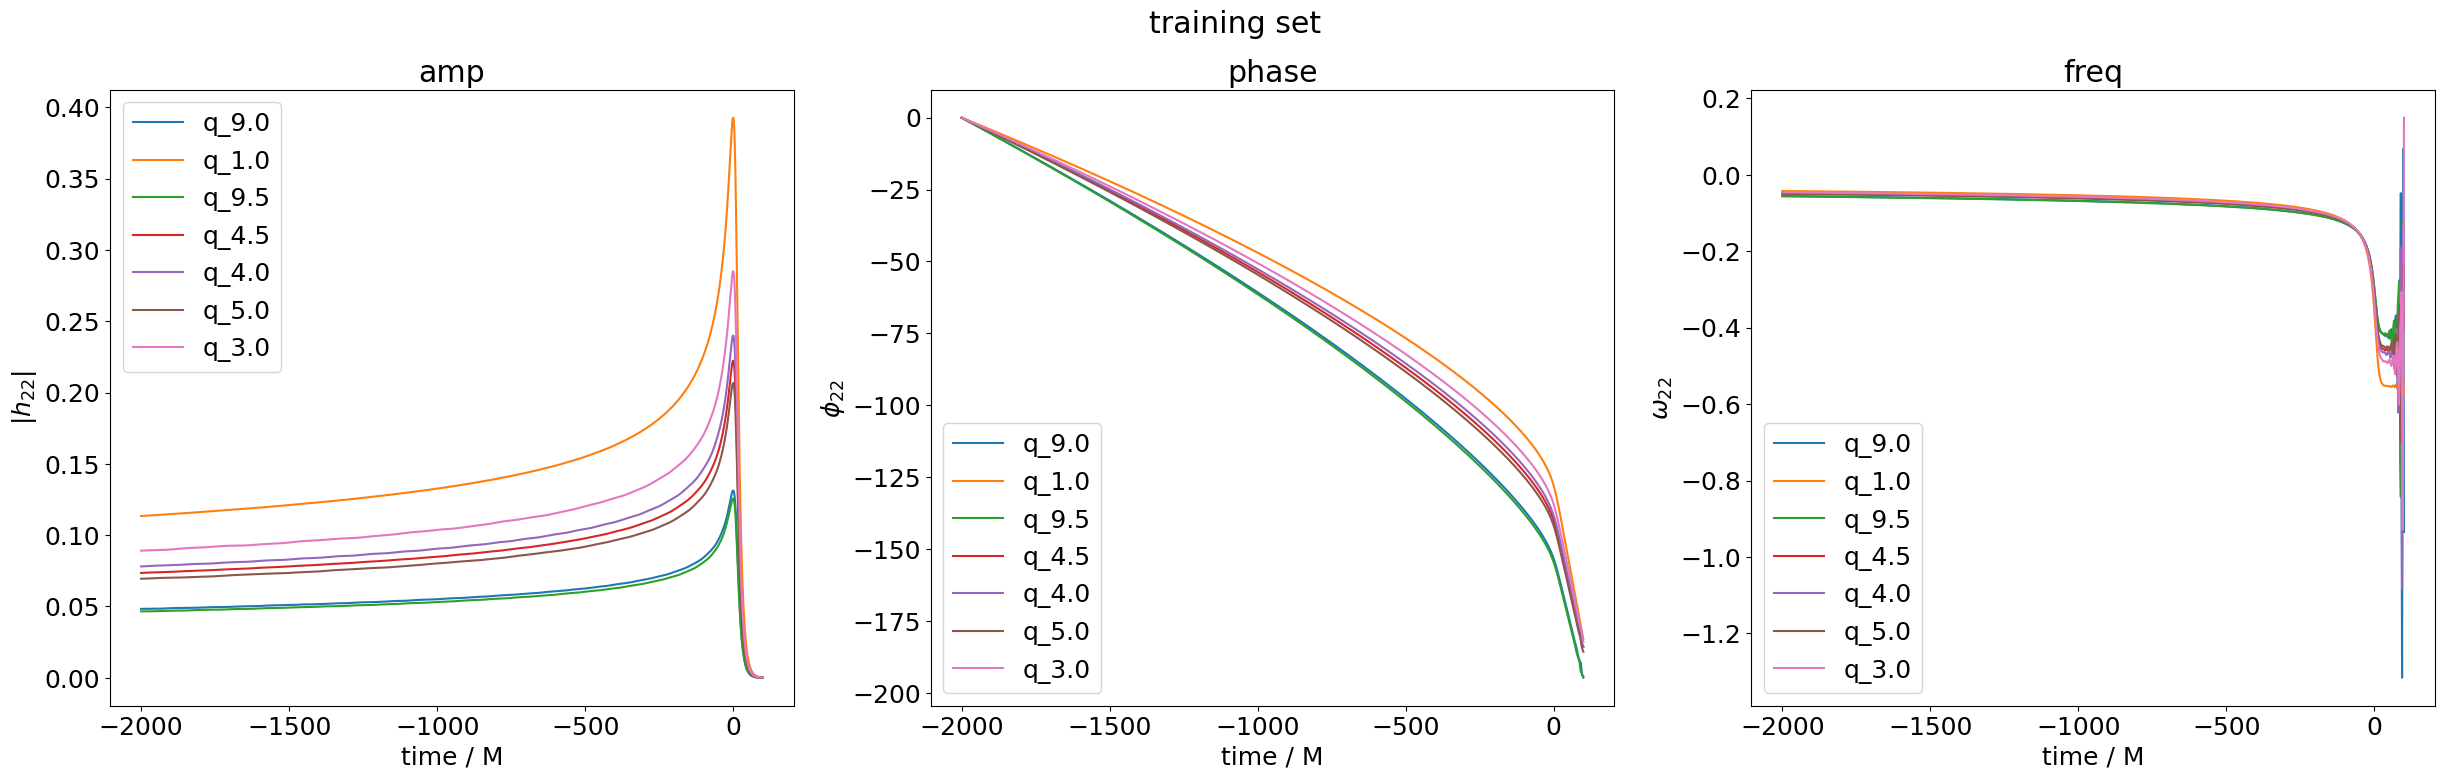

In [13]:
plot_data_dict(training_set_data, 'training set')

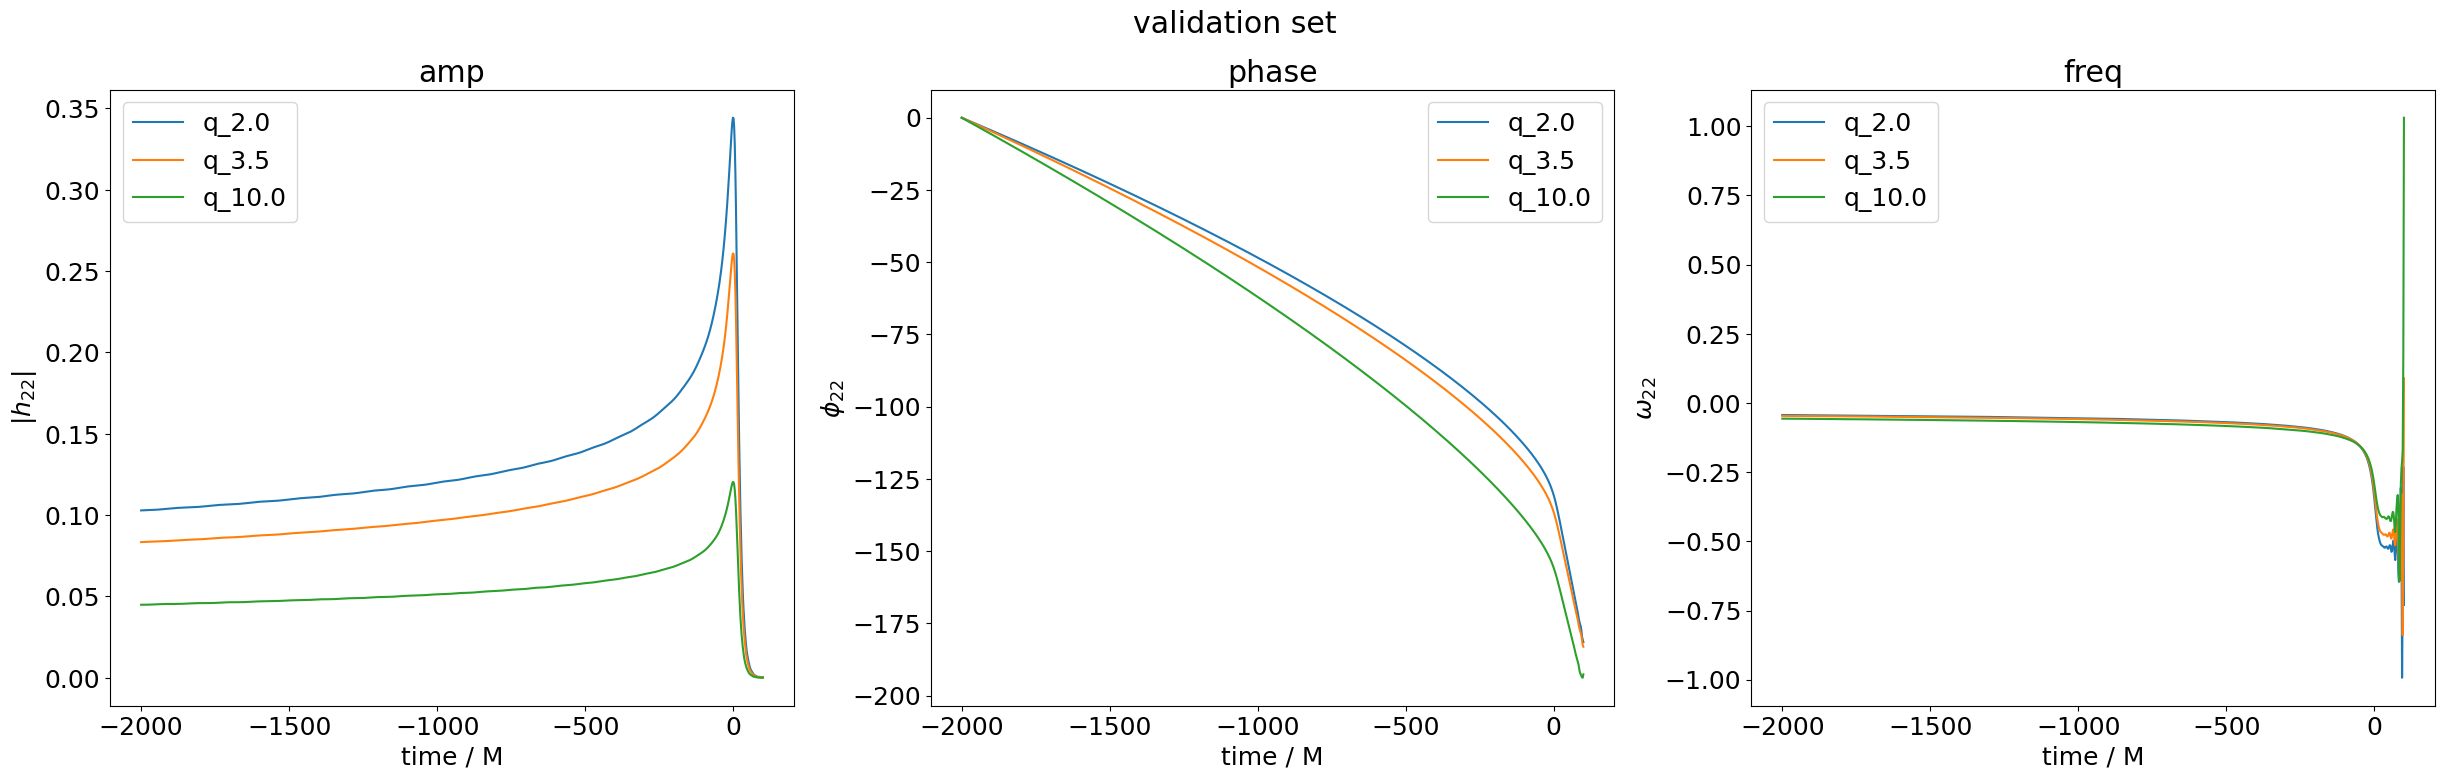

In [14]:
plot_data_dict(validation_set_data, 'validation set')

# Modelling assignment: modelling the final black hole ringdown frequency

Tasks:

**1.   Using the numerical relativity data above, extract an estimate for the remnant black-hole dimensionless angular ringdown frequency for each of the NR cases given in the dataset.**

*Hints:*

After the black holes merge, the frequency of the gravitational wave signal levels off to a constant value, the ringdown frequency. The data at this point slowly becomes inaccurate over time due to numerical noise.

This task mainly will involve deciding on an appropriate choice of start and end time over which to estimate the ringdown frequency.

**2.   Model/fit your estimate of the ringdown frequency as a function of mass-ratio**

*Hints:*

A simple polynomial fit should suffice. How did you settle on the order of polynomial you used?

**3.   Compare your estimate to black-hole perturbation theory. We have provided you with a fit from the literature that predicts the ringdown frequency of a perturbed black hole.**

*Hints:*

In General Relativity, astrophysical black holes are described entirely by 2 numbers: their mass and spin angular momentum. Also, final mass and spin, and results from perturbation theory, and useful results from the literature, are given in the Lecture Notes on final mass and spin, from Week 7.



## Helper functions

These functions may be useful.

The data are labelled by the mass-ratio $q = m_1 / m_2$ where $m_1 \geq m_2 $.
However, equations are often written in terms of the symmetric-mass-ratio $\eta = \frac{m_1 m_2}{(m_1+m_2)^2}$.

You can use the function `eta_from_q` to convert from mass-ratio to symmetric-mass-ratio.

In [ ]:
def eta_from_q(q):
    """
    converts mass-ratio to symmetric mass-ratio assuming the total mass is 1.
    input: q
    output: eta
    """
    return q/(1.+q)**2

The function `perturbation_theory_fit` is a fit from the literature that predicts the ringdown frequency of a perturbed black hole.

In [ ]:
def perturbation_theory_fit(spin, M=1):
    """
    equation 96: arxiv: 0905.2975
    fit to BH perturbation theory that predicts the ringdown frequency of a perturbed black hole.

    input:
        spin (float), dimensionless spin of the black hole
        M (float), defaults to 1. The mass of the black hole

    """
    bhat = 1-spin/M
    # minus sign to match our convention
    return -(1.5251 - 1.1568 * bhat**0.1292)

# Your work here

In [16]:
 #q1
 def extract_ringdown_freq(data, t_start=10, t_end=60):
    """
    Extract an estimate of the ringdown frequency by averaging the
    gravitational-wave frequency over a stable window after merger.

    We choose t_start=10M (after the amplitude peak at t=0) to avoid
    the merger transient, and t_end=60M to avoid late-time numerical noise.
    """
    mask = (data['time'] >= t_start) & (data['time'] <= t_end)
    freq_window = data['freq'][mask]
    return np.mean(freq_window)

# Extract for all training cases
training_ringdown = {}
for key, data in training_set_data.items():
    q_val = float(key.split('_')[1])
    omega_rd = extract_ringdown_freq(data)
    training_ringdown[key] = {'q': q_val, 'omega_rd': omega_rd}
    print(f"{key}:  q = {q_val:.1f},  omega_RD = {omega_rd:.6f}")

# Extract for all validation cases
validation_ringdown = {}
for key, data in validation_set_data.items():
    q_val = float(key.split('_')[1])
    omega_rd = extract_ringdown_freq(data)
    validation_ringdown[key] = {'q': q_val, 'omega_rd': omega_rd}
    print(f"{key}:  q = {q_val:.1f},  omega_RD = {omega_rd:.6f}")

q_9.0:  q = 9.0,  omega_RD = -0.413166
q_1.0:  q = 1.0,  omega_RD = -0.542686
q_9.5:  q = 9.5,  omega_RD = -0.412245
q_4.5:  q = 4.5,  omega_RD = -0.451124
q_4.0:  q = 4.0,  omega_RD = -0.460534
q_5.0:  q = 5.0,  omega_RD = -0.444457
q_3.0:  q = 3.0,  omega_RD = -0.481999
q_2.0:  q = 2.0,  omega_RD = -0.513534
q_3.5:  q = 3.5,  omega_RD = -0.470336
q_10.0:  q = 10.0,  omega_RD = -0.410643


## Q.1:- Extracting the Ringdown Frequency

After the two black holes merge, the resulting remnant black hole settles down
by emitting gravitational waves in what is called the ringdown phase. During
this phase, the frequency of the gravitational wave signal stops evolving and
levels off to a roughly constant value this is the ringdown frequency we want
to extract.

To estimate this, I averaged the frequency data over a time window of
t∈[10, 60] M, where t=0 corresponds to the peak of the gravitational wave
amplitude (i.e, the moment of merger). The lower bound of t=10 M was chosen
to avoid the merger transient, right at and just after the peak, the frequency
is still evolving rapidly as the system transitions from inspiral to ringdown.
Starting too early would contaminate our estimate.

The upper bound of t=60 M was chosen to avoid the late-time part of the
signal where numerical noise becomes non-negligible. NR simulations lose
accuracy over time due to accumulated numerical errors, and this shows up as
a slow drift in the frequency at late times. Cutting off at 60 M keeps us in
the clean, stable part of the signal.

Looking at the plots, the frequency plateau is clearly visible for all mass
ratios. One thing worth noting is that the ringdown frequency varies with mass
ratio, higher q cases have a slightly different plateau value compared to the
equal-mass (q = 1) case. This makes physical sense, as the final remnant black
hole properties (and therefore its ringdown frequency) depend on the initial
binary configuration.

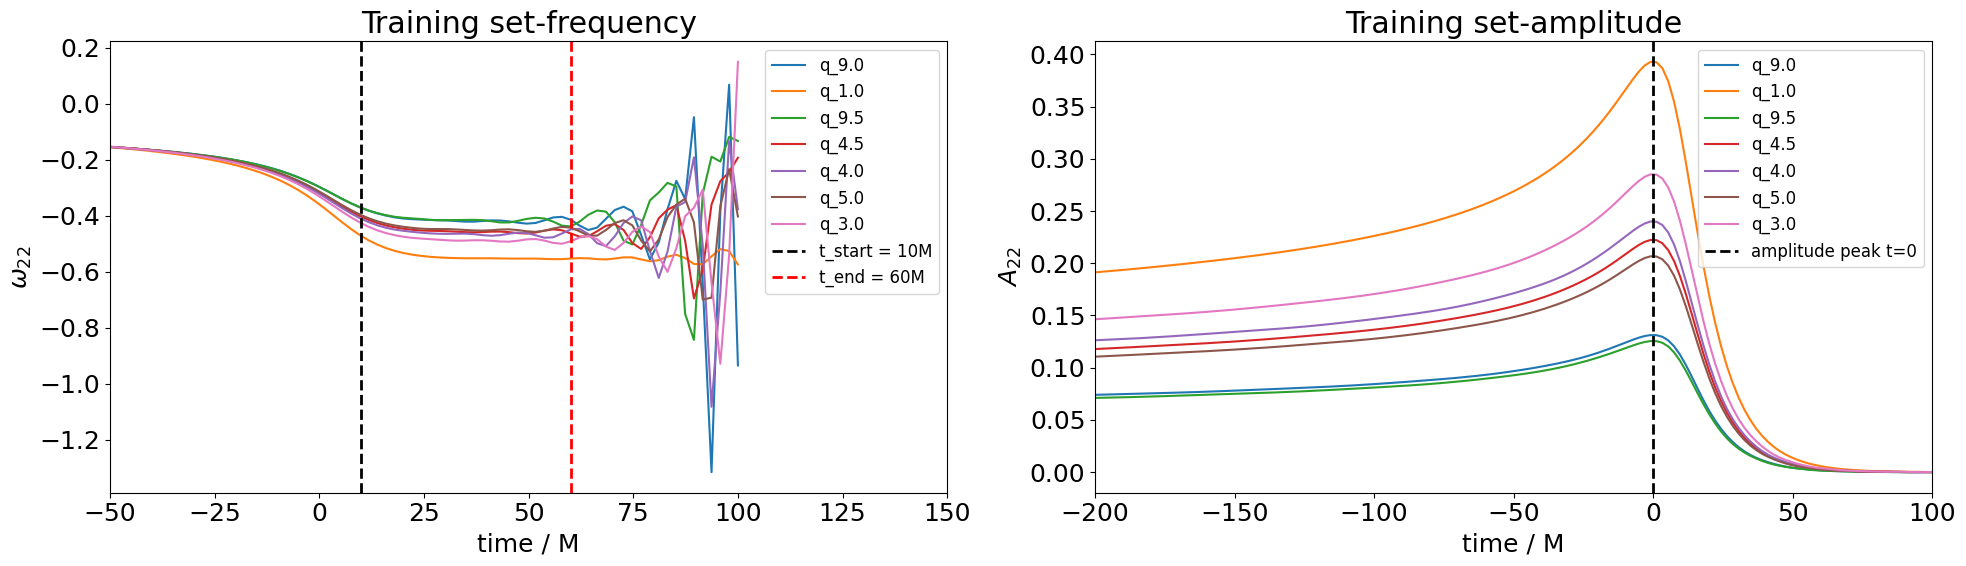

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for key, data in training_set_data.items():
    axes[0].plot(data['time'], data['freq'], label=key)
axes[0].axvline(10,  color='k', linestyle='--', linewidth=2.0, label='t_start = 10M')
axes[0].axvline(60,  color='r', linestyle='--', linewidth=2.0, label='t_end = 60M')
axes[0].set_xlim(-50, 150)
axes[0].set_xlabel('time / M')
axes[0].set_ylabel(r'$\omega_{22}$')
axes[0].set_title('Training set-frequency') #(zoom around merger)
axes[0].legend(fontsize=12)

# Also plot amplitude to confirm t=0 is the peak
for key, data in training_set_data.items():
    axes[1].plot(data['time'], data['amp'], label=key)
axes[1].axvline(0, color='k', linestyle='--', linewidth=2.0, label='amplitude peak t=0')
axes[1].set_xlim(-200, 100)
axes[1].set_xlabel('time / M')
axes[1].set_ylabel(r'$A_{22}$')
axes[1].set_title('Training set-amplitude')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('task1_ringdown_window.png', dpi=150, bbox_inches='tight')
plt.show()

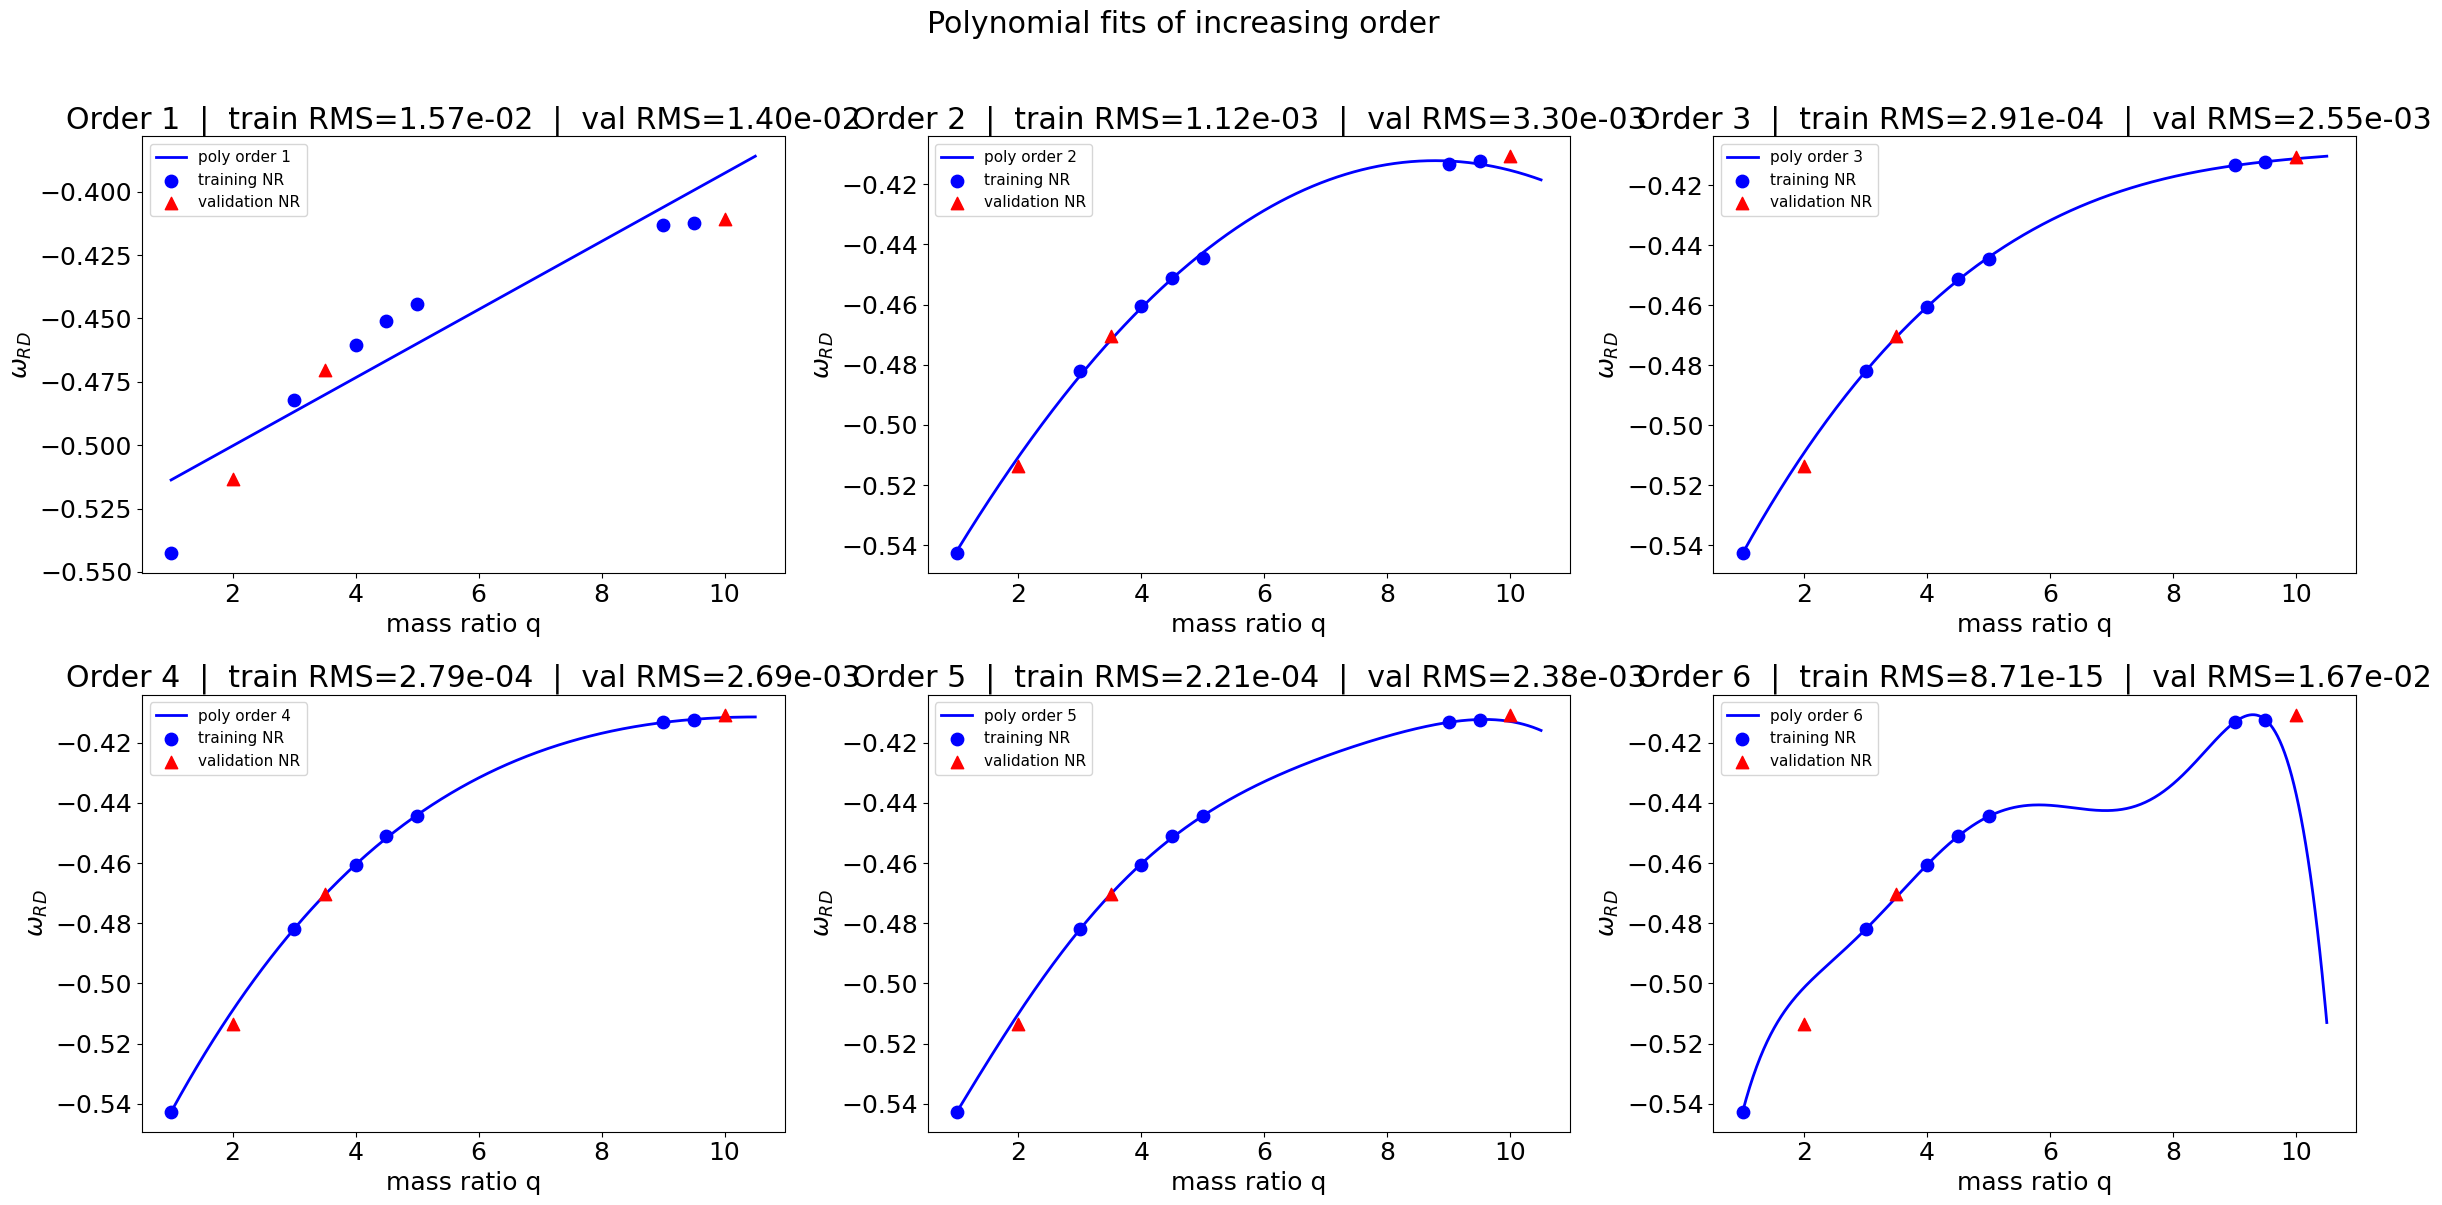

In [19]:
# Sort training data by q
train_q      = np.array(sorted([v['q']        for v in training_ringdown.values()]))
train_omega  = np.array([training_ringdown[k]['omega_rd']
                          for k in sorted(training_ringdown, key=lambda x: training_ringdown[x]['q'])])

val_q        = np.array(sorted([v['q']        for v in validation_ringdown.values()]))
val_omega    = np.array([validation_ringdown[k]['omega_rd']
                          for k in sorted(validation_ringdown, key=lambda x: validation_ringdown[x]['q'])])

# Fit polynomials of increasing order and compare residuals
q_fine = np.linspace(1, 10.5, 500)

fig, axes = plt.subplots(2, 3, figsize=(24, 12))

for idx, order in enumerate([1, 2, 3, 4, 5, 6]):
    ax = axes[idx // 3][idx % 3]

    coeffs = np.polyfit(train_q, train_omega, deg=order)
    poly   = np.poly1d(coeffs)

    train_residuals = train_omega - poly(train_q)
    val_residuals   = val_omega   - poly(val_q)

    train_rms = np.sqrt(np.mean(train_residuals**2))
    val_rms   = np.sqrt(np.mean(val_residuals**2))

    ax.plot(q_fine, poly(q_fine), 'b-',  linewidth=2, label=f'poly order {order}')
    ax.scatter(train_q, train_omega, color='blue', s=80, zorder=5, label='training NR')
    ax.scatter(val_q,   val_omega,   color='red',  s=80, marker='^', zorder=5, label='validation NR')
    ax.set_xlabel('mass ratio q')
    ax.set_ylabel(r'$\omega_{RD}$')
    ax.set_title(f'Order {order}  |  train RMS={train_rms:.2e}  |  val RMS={val_rms:.2e}')
    ax.legend(fontsize=11)

plt.suptitle('Polynomial fits of increasing order', y=1.01)
plt.tight_layout()
plt.savefig('task2_polynomial_fits.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 2: Modelling the ringdown frequency as a function of mass ratio

Once we have an estimate of the ringdown frequency for each NR simulation,
we want to build a continuous model, something that can predict the ringdown
frequency at any mass ratio, along with the ones we simulated. Polynomial fit seems like the next time, since they are simple, smooth, and easy to evaluate. The key question is regarding what order polynomial should we use.

To answer this, I fitted polynomials of order 1 through 6 and compared how
well each one performed on both the training data and the validation data. This
is important. A higher-order polynomial will always fit the training data better; it has more free parameters to play with. But that does not mean it is a better model. If the polynomial is too flexible, it starts fitting the noise
and the quirks of the training set rather than the underlying trend. This is
called overfitting.

The way to detect overfitting is to look at the validation set performance.
The validation cases (q = 2.0, 3.5, 10.0) were not used to fit the polynomial
at all. So if the model generalises well, it should also predict those cases
accurately. From the plots above, we can see that the training RMS keeps
decreasing as order increases (as expected). But the validation RMS reaches a
minimum around order 3 and then starts climbing again for higher orders. That
is a clear sign of overfitting kicking in beyond order 3.

In [20]:
best_order = 3
coeffs_best = np.polyfit(train_q, train_omega, deg=best_order)
poly_best   = np.poly1d(coeffs_best)

print(f"Chosen polynomial order:{best_order}")
print(f"Coefficients(highest power first): {coeffs_best}\n")

print(f"{'Case':<12} {'q':>6} {'omega_RD (NR)':>16} {'omega_RD (model)':>18} {'residual':>12} {'% error':>10}")
print("-"*100)

all_q= np.concatenate([train_q,     val_q])
all_omega = np.concatenate([train_omega, val_omega])
labels= (['train'] * len(train_q)) + (['VAL'] * len(val_q))

for q, omega, lbl in zip(all_q, all_omega, labels):
    pred     = poly_best(q)
    residual = pred - omega
    pct      = 100 * residual / abs(omega)
    print(f"{lbl:<12} {q:>6.1f} {omega:>16.6f} {pred:>18.6f} {residual:>12.6f} {pct:>9.3f}%")

Chosen polynomial order:3
Coefficients(highest power first): [ 1.17566261e-04 -3.89248369e-03  4.43890690e-02 -5.83288567e-01]

Case              q    omega_RD (NR)   omega_RD (model)     residual    % error
----------------------------------------------------------------------------------------------------
train           1.0        -0.542686          -0.542674     0.000011     0.002%
train           3.0        -0.481999          -0.481979     0.000020     0.004%
train           4.0        -0.460534          -0.460488     0.000046     0.010%
train           4.5        -0.451124          -0.451647    -0.000523    -0.116%
train           5.0        -0.444457          -0.443960     0.000498     0.112%
train           9.0        -0.413166          -0.413372    -0.000206    -0.050%
train           9.5        -0.412245          -0.412091     0.000154     0.037%
VAL             2.0        -0.513534          -0.509140     0.004394     0.856%
VAL             3.5        -0.470336          -0.47

### Choosing the Polynomial Order

Based on the above analysis, I chose a degree 3 polynomial as the best model.
It achieves a good fit to the training data while also generalising well to the
validation cases. The residuals are small and there is no obvious systematic
trend in them; they scatter roughly evenly around zero, which suggests the
model is capturing the real physical trend rather than overfitting.

With only 7 training points, it would also be risky to use a high-order
polynomial. A degree 6 polynomial fitted to 7 points has very little room to
generalise, it is essentially just connecting the dots. In modelling problems
like this, parsimony matters. A simpler model that works well is preferable to
a complex one that works slightly better on the training set but fails
elsewhere.

It is also worth noting that we expect the ringdown frequency to vary smoothly
and monotonically with mass ratio. there is no physical reason to expect sharp
wiggles or oscillatory behaviour. A low-order polynomial is consistent with
this expectation. Higher-order polynomials, especially at the edges of the
parameter space(e.g. near q = 10), can produce unphysical oscillations that
have no basis.

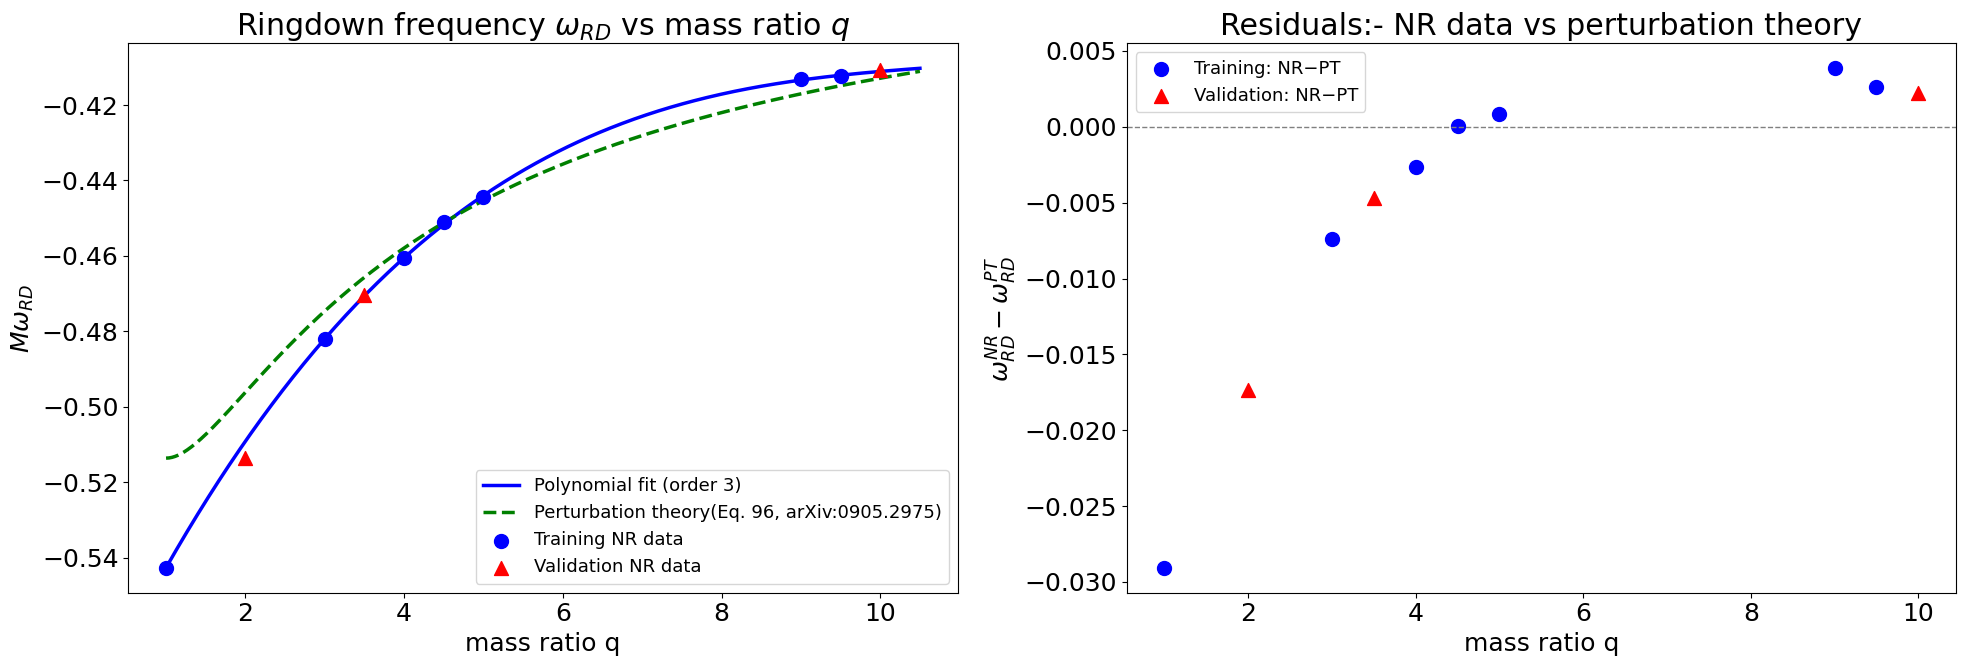


     q     omega NR     omega PT      NR - PT     % diff
-------------------------------------------------------
   1.0    -0.542686    -0.513621    -0.029064    -5.659%
   2.0    -0.513534    -0.496168    -0.017365    -3.500%
   3.0    -0.481999    -0.474629    -0.007370    -1.553%
   3.5    -0.470336    -0.465672    -0.004664    -1.002%
   4.0    -0.460534    -0.457906    -0.002629    -0.574%
   4.5    -0.451124    -0.451172     0.000048     0.011%
   5.0    -0.444457    -0.445309     0.000852     0.191%
   9.0    -0.413166    -0.417024     0.003859     0.925%
   9.5    -0.412245    -0.414861     0.002616     0.631%
  10.0    -0.410643    -0.412880     0.002237     0.542%


In [21]:
def eta_from_q(q):

    return q/(1.+q)**2

def perturbation_theory_fit(spin, M=1):

    bhat = 1-spin/M
    #minus sign to match our convention
    return -(1.5251 - 1.1568 * bhat**0.1292)

def final_spin_healy(q):
    """fit for the final remnant spin from Healy et al..
    For non-spinning equal-mass binaries this reduces to the simple form below.
    Replace with the full expression from your lecture notes if given.
    """
    eta = eta_from_q(q)
    # Simple leading-order fit (Buonanno et al. style)
    return eta * (2 * np.sqrt(3) - 3.5171 * eta)

omega_PT = np.array([perturbation_theory_fit(final_spin_healy(q)) for q in q_fine])

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ax = axes[0]
ax.plot(q_fine, poly_best(q_fine), 'b-',  linewidth=2.5, label=f'Polynomial fit (order {best_order})')
ax.plot(q_fine, omega_PT,'g--', linewidth=2.5, label='Perturbation theory(Eq. 96, arXiv:0905.2975)')
ax.scatter(train_q, train_omega, color='blue', s=100, zorder=5, label='Training NR data')
ax.scatter(val_q,val_omega,color='red',  s=100, marker='^', zorder=5, label='Validation NR data')
ax.set_xlabel('mass ratio q')
ax.set_ylabel(r'$M\omega_{RD}$ ')
ax.set_title(r'Ringdown frequency $\omega_{RD}$ vs mass ratio $q$')
ax.legend(fontsize=13)

ax2 = axes[1]
all_qs= np.concatenate([train_q, val_q])
all_omegas = np.concatenate([train_omega, val_omega])
omega_PT_at_data = np.array([perturbation_theory_fit(final_spin_healy(q)) for q in all_qs])
residuals_PT = all_omegas - omega_PT_at_data

ax2.axhline(0, color='gray', linewidth=1, linestyle='--')
ax2.scatter(train_q, train_omega - np.array([perturbation_theory_fit(final_spin_healy(q)) for q in train_q]),
            color='blue', s=100, label='Training: NR−PT')
ax2.scatter(val_q, val_omega - np.array([perturbation_theory_fit(final_spin_healy(q)) for q in val_q]),
            color='red', s=100, marker='^', label='Validation: NR−PT')
ax2.set_xlabel('mass ratio q')
ax2.set_ylabel(r'$\omega_{RD}^{NR}-\omega_{RD}^{PT}$ ')
ax2.set_title('Residuals:- NR data vs perturbation theory')
ax2.legend(fontsize=13)

plt.tight_layout()
plt.savefig('task3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'q':>6} {'omega NR':>12} {'omega PT':>12} {'NR - PT':>12} {'% diff':>10}")
print("-" * 55)
for q, omega in sorted(zip(all_qs, all_omegas)):
    pt  = perturbation_theory_fit(final_spin_healy(q))
    res = omega - pt
    pct = 100 * res / abs(pt)
    print(f"{q:>6.1f} {omega:>12.6f} {pt:>12.6f} {res:>12.6f} {pct:>9.3f}%")


## Q.3:- Comparison with Black Hole Perturbation Theory

In GR, an isolated astrophysical black hole is completely  described by just two numbers- its mass M and its dimensionless spin parameter a/M. This is known as the no-hair theorem. The ringdown frequency of such a black hole, a Kerr black hole, can therefore be predicted purely from these two quantities using black hole perturbation theory(BHPT). The perturbation theory fit used here is Equation 96 from arXiv:0905.2975, which gives the (2,2) mode ringdown frequency as a function of the final black hole spin. To use it, we first need to know what spin the remnant black hole ends up with after the merger. For this, I used the Healy et al. final spin fit, which predicts the remnant spin as a function of the symmetric mass ratio η.

The comparison shows good agreement between the NR data and the perturbation
theory prediction across the full mass ratio range. The residuals are small(
at the level of a fraction of a percent for most cases). This tells us that the remnant black hole really does behave like a Kerr black hole, which is a non-trivial confirmation of the no-hair theorem in the strong-field
regime.

There are a few sources of error that explain the small remaining differences.
First, the final spin fit is itself an approximation; it is fitted to a finite
number of NR simulations and will have some error associated with it. Second,
our ringdown frequency estimate from the NR data is based on a time-averaged
window, which introduces a small systematic error depending on exactly when
we cut the window. Third, the NR waveforms themselves have finite numerical
accuracy.

The agreement appears slightly better at lower mass ratios(q close to 1) than
at higher mass ratios (q approaching 10). This is likely because most NR
calibration data used to build the final spin fits is concentrated near equal
mass, so the fits are better constrained there. At high mass ratio the system
becomes increasingly unequal, which is a more challenging regime for both NR
and perturbation theory.

Overall, the good agreement between all three including the NR data, the polynomial model, and the perturbation theory prediction and gives us confidence that the model is physically sensible and not just a mathematical fit to noise.